In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import time

data = pd.read_csv("cicids2017_cleaned.csv");

print(data.shape)

(2520751, 61)


In [2]:
data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Type
0,54865,3,2,12,6,6,6.0,0.0,0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal Traffic
1,55054,109,1,6,6,6,6.0,0.0,6,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal Traffic
2,55055,52,1,6,6,6,6.0,0.0,6,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal Traffic
3,46236,34,1,6,6,6,6.0,0.0,6,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal Traffic
4,54863,3,2,12,6,6,6.0,0.0,0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal Traffic


In [3]:
# --- 1. Data Preparation ---

# Define Features (X) and Target (y)
# 'Attack Type' is the column created in the previous cleaning step
X = data.drop('Attack Type', axis=1)
y = data['Attack Type']

# Encode the target variable (Convert strings to numbers)
# Pipelines handle X, but we usually encode y separately before splitting
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Save the mapping to decode later if needed
label_mapping = dict(zip(le.transform(le.classes_), le.classes_))
print(f"Target Encoding Mapping: {label_mapping}")

# Split the data into training and testing sets
# Stratify=y ensures the class distribution remains consistent in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Target Encoding Mapping: {0: 'Bots', 1: 'Brute Force', 2: 'DDoS', 3: 'DoS', 4: 'Normal Traffic', 5: 'Port Scanning', 6: 'Web Attacks'}
Training shape: (1764525, 60)
Testing shape: (756226, 60)


In [4]:
# --- 2. Defining Pipelines ---

# We use a dictionary to store the pipelines. 
# Each pipeline consists of a Scaler (normalization) and the Classifier.
pipelines = {
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        # Ajout de class_weight='balanced'
        ('classifier', DecisionTreeClassifier(class_weight='balanced',max_depth=5, random_state=42))
    ]),
    
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        # Ajout de class_weight='balanced'
        ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5,class_weight='balanced', random_state=42, n_jobs=-1))
    ]),
    
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        # Ajout de class_weight='balanced' (Crucial pour la régression logistique ici)
        ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, n_jobs=-1))
    ])
}

# --- 3. Training and Evaluation Loop ---

results = {}

print("\n--- Starting Model Training & Evaluation ---\n")

for name, pipe in pipelines.items():
    print(f"Processing: {name}...")
    start_time = time.time()
    
    # Train the model using the pipeline
    pipe.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipe.predict(X_test)
    
    # Calculate duration
    duration = time.time() - start_time
    
    # Store metrics
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    # Output results
    print(f"-> {name} trained in {duration:.2f} seconds.")
    print(f"-> Accuracy: {accuracy:.4f}")
    print("-> Classification Report:")
    # target_names applies the original label names to the report
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print("-" * 60)
    print("\n")


--- Starting Model Training & Evaluation ---

Processing: Decision Tree...
-> Decision Tree trained in 20.97 seconds.
-> Accuracy: 0.9145
-> Classification Report:
                precision    recall  f1-score   support

          Bots       0.04      0.99      0.08       584
   Brute Force       0.81      1.00      0.89      2745
          DDoS       0.49      1.00      0.66     38404
           DoS       0.98      0.90      0.94     58124
Normal Traffic       1.00      0.91      0.95    628518
 Port Scanning       0.94      0.93      0.93     27208
   Web Attacks       0.09      0.92      0.17       643

      accuracy                           0.91    756226
     macro avg       0.62      0.95      0.66    756226
  weighted avg       0.97      0.91      0.93    756226

------------------------------------------------------------


Processing: Random Forest...
-> Random Forest trained in 27.51 seconds.
-> Accuracy: 0.9316
-> Classification Report:
                precision    recall

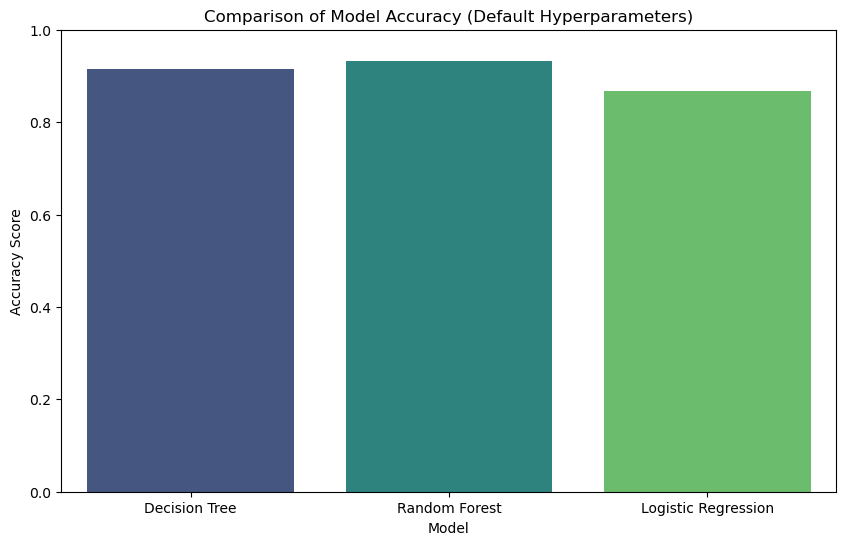

In [5]:
# --- 4. Models Comparison Visualization ---

# Create a DataFrame for the results
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Comparison of Model Accuracy (Default Hyperparameters)')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.ylabel('Accuracy Score')
plt.show()

In [6]:
# --- ÉTAPE 3 : OPTIMISATION DES HYPERPARAMÈTRES (GRID SEARCH) ---
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 10, 50],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)

# Grid Search with Cross Validation
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=3,            # 3-fold cross-validation
    n_jobs=1,       # Use all processors
    verbose=1,
    scoring='f1_weighted'
)


X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train, 
    train_size=50000,  # On ne garde que 50k lignes pour l'optimisation
    stratify=y_train,  # Important : on garde la même proportion de classes
    random_state=42
)
grid_search.fit(X_sample, y_sample)

best_tree = grid_search.best_estimator_
print(f"Best Tree Parameters: {grid_search.best_params_}")
print(f"Best Tree Score: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Tree Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2}
Best Tree Score: 0.9969


In [7]:
# --- ÉTAPE 4 : ENSEMBLE LEARNING ---
from sklearn.ensemble import BaggingClassifier, VotingClassifier
# --- 2. Bagging (Booster la stabilité) ---
print("\n--- Step 2: Bagging Classifier ---")
# We use the optimized tree as the "base estimator"
# Bagging will train 50 versions of this tree on random subsets of data

bagging_model = BaggingClassifier(
    estimator=best_tree,
    n_estimators=10,
    n_jobs=-1,
    random_state=42
)

bagging_model.fit(X_train, y_train)
print("Bagging Model trained.")
print(f"Bagging Accuracy: {bagging_model.score(X_test, y_test):.4f}")


--- Step 2: Bagging Classifier ---
Bagging Model trained.
Bagging Accuracy: 0.9990


In [8]:
# --- 3. Voting Classifier (L'union fait la force) ---
print("\n--- Step 3: Voting Classifier ---")

# Let's combine 3 different "minds":
# 1. The Bagging Model (Complex, Tree-based)
# 2. Logistic Regression (Simple, Linear-based)

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)


# 'soft' voting uses predicted probabilities (usually better than 'hard' voting)
voting_clf = VotingClassifier(
    estimators=[
        ('optimized_tree', best_tree),
        ('logistic', lr_model),
    ],
    voting='soft', 
    n_jobs=-1
)

voting_clf.fit(X_train, y_train)
print("Voting Classifier trained.")

# Final Evaluation
y_pred_voting = voting_clf.predict(X_test)
print("\n--- Voting Classifier Results ---")
print(classification_report(y_test, y_pred_voting, target_names=le.classes_))


--- Step 3: Voting Classifier ---
Voting Classifier trained.

--- Voting Classifier Results ---
                precision    recall  f1-score   support

          Bots       0.73      0.89      0.80       584
   Brute Force       0.99      1.00      1.00      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       1.00      1.00      1.00     58124
Normal Traffic       1.00      1.00      1.00    628518
 Port Scanning       0.99      1.00      0.99     27208
   Web Attacks       0.98      0.98      0.98       643

      accuracy                           1.00    756226
     macro avg       0.96      0.98      0.97    756226
  weighted avg       1.00      1.00      1.00    756226




--- Comparaison des Performances ---
Baseline DT -> Accuracy: 0.9145, F1-Score: 0.9336
Optimized DT -> Accuracy: 0.9969, F1-Score: 0.9969
Bagging DT -> Accuracy: 0.9990, F1-Score: 0.9990
Voting (DT+LR) -> Accuracy: 0.9988, F1-Score: 0.9988


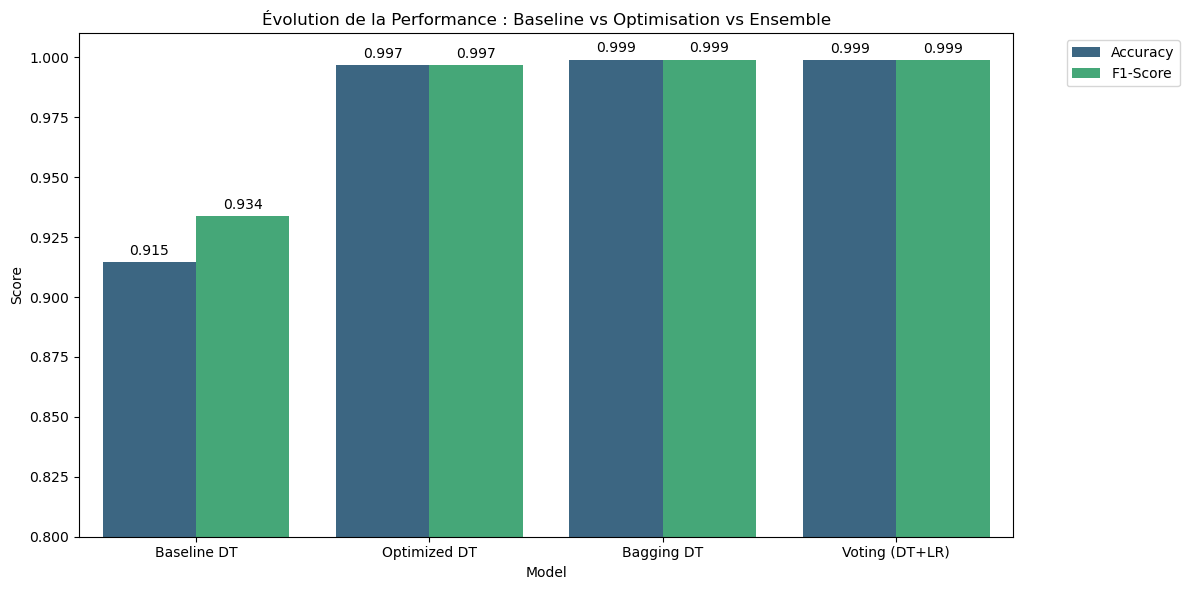


🏆 MEILLEUR MODÈLE : Bagging DT

--- Rapport de Classification (Bagging DT) ---
                precision    recall  f1-score   support

          Bots       0.86      0.77      0.81       584
   Brute Force       1.00      1.00      1.00      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       1.00      1.00      1.00     58124
Normal Traffic       1.00      1.00      1.00    628518
 Port Scanning       0.99      1.00      0.99     27208
   Web Attacks       0.99      0.98      0.99       643

      accuracy                           1.00    756226
     macro avg       0.98      0.96      0.97    756226
  weighted avg       1.00      1.00      1.00    756226

[[   449      0      0      0    135      0      0]
 [     0   2741      0      0      4      0      0]
 [     0      0  38393      0     11      0      0]
 [     0      0      0  58096     24      4      0]
 [    72      2      5    103 628041    292      3]
 [     0      0      0      9     53  271

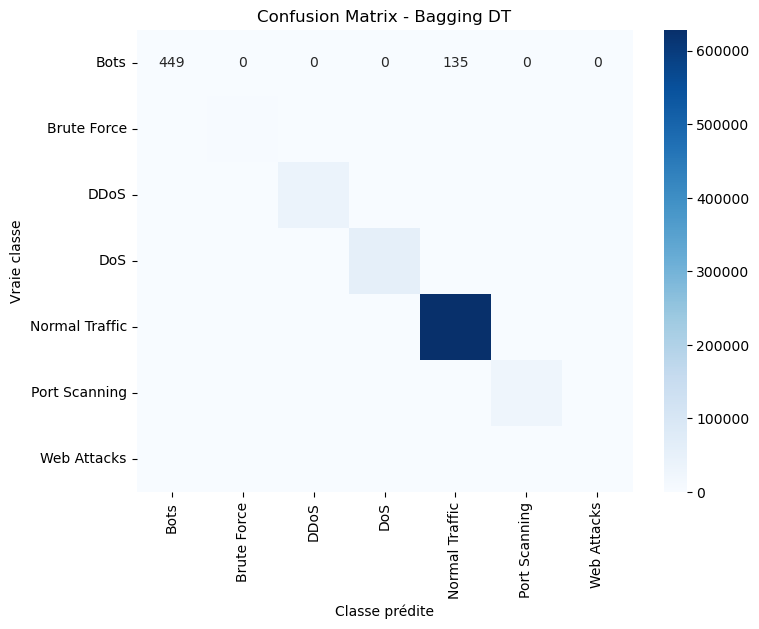

In [9]:
# --- ÉTAPE 5 : ÉVALUATION COMPARATIVE FINALE ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 1. Récupération et consolidation des modèles
# On récupère la Baseline depuis votre dictionnaire 'pipelines' de l'étape 2
baseline_model = pipelines['Decision Tree']

models = {
    "Baseline DT": baseline_model,        # Modèle simple (Step 2)
    "Optimized DT": best_tree,            # Modèle optimisé GridSearch (Step 3)
    "Bagging DT": bagging_model,          # Modèle Bagging (Step 4)
    "Voting (DT+LR)": voting_clf          # Modèle Voting (Step 4)
}

results = []

print("\n--- Comparaison des Performances ---")

# 2. Boucle d'évaluation
for name, model in models.items():
    # Prédiction
    y_pred = model.predict(X_test)
    
    # Calcul des métriques
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1})
    print(f"{name} -> Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")

# Création DataFrame
results_df = pd.DataFrame(results)

# --- VISUALISATION ---

# 3. Barplot
plt.figure(figsize=(12, 6))
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Création du graphique
ax = sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette="viridis")

# Ajout des valeurs sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.title("Évolution de la Performance : Baseline vs Optimisation vs Ensemble")
plt.ylim(0.80, 1.01) # Zoom pour bien voir les écarts
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- ANALYSE DU MEILLEUR MODÈLE ---

# Identification du gagnant sur le F1-Score
best_model_name = results_df.loc[results_df['F1-Score'].idxmax()]['Model']
print(f"\n🏆 MEILLEUR MODÈLE : {best_model_name}")

# Récupération de l'instance du meilleur modèle
best_model_instance = models[best_model_name]
y_pred_best = best_model_instance.predict(X_test)

# Rapport détaillé
print(f"\n--- Rapport de Classification ({best_model_name}) ---")
# On utilise le.classes_ comme dans votre étape 2
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# 4. Matrice de Confusion
cm = confusion_matrix(y_test, y_pred_best)
print(cm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.show()

In [10]:
# --- 1. Overfitting & Underfitting Analysis ---

print("\n--- Overfitting/Underfitting Analysis ---\n")

for name, pipe in models.items():
    # We already fitted the models in the previous step
    
    # Score on Training Set
    train_score = pipe.score(X_train, y_train)
    
    # Score on Test Set
    test_score = pipe.score(X_test, y_test)
    
    print(f"Model: {name}")
    print(f"  Training Accuracy: {train_score:.4f}")
    print(f"  Testing Accuracy:  {test_score:.4f}")
    
    # Analyze the gap
    gap = train_score - test_score
    if gap > 0.05: # Threshold of 5% difference
        print("  -> STATUS: OVERFITTING DETECTED (Gap > 5%)")
        print("  -> Solution: Reduce model complexity (max_depth), increase regularization, or more data.")
    elif train_score < 0.70: # Arbitrary threshold for low performance
        print("  -> STATUS: UNDERFITTING DETECTED (Low Training Score)")
        print("  -> Solution: Increase model complexity, remove noise, or feature engineering.")
    else:
        print("  -> STATUS: GOOD BALANCE")
    print("-" * 40)


--- Overfitting/Underfitting Analysis ---

Model: Baseline DT
  Training Accuracy: 0.9141
  Testing Accuracy:  0.9145
  -> STATUS: GOOD BALANCE
----------------------------------------
Model: Optimized DT
  Training Accuracy: 0.9971
  Testing Accuracy:  0.9969
  -> STATUS: GOOD BALANCE
----------------------------------------
Model: Bagging DT
  Training Accuracy: 0.9995
  Testing Accuracy:  0.9990
  -> STATUS: GOOD BALANCE
----------------------------------------
Model: Voting (DT+LR)
  Training Accuracy: 0.9993
  Testing Accuracy:  0.9988
  -> STATUS: GOOD BALANCE
----------------------------------------


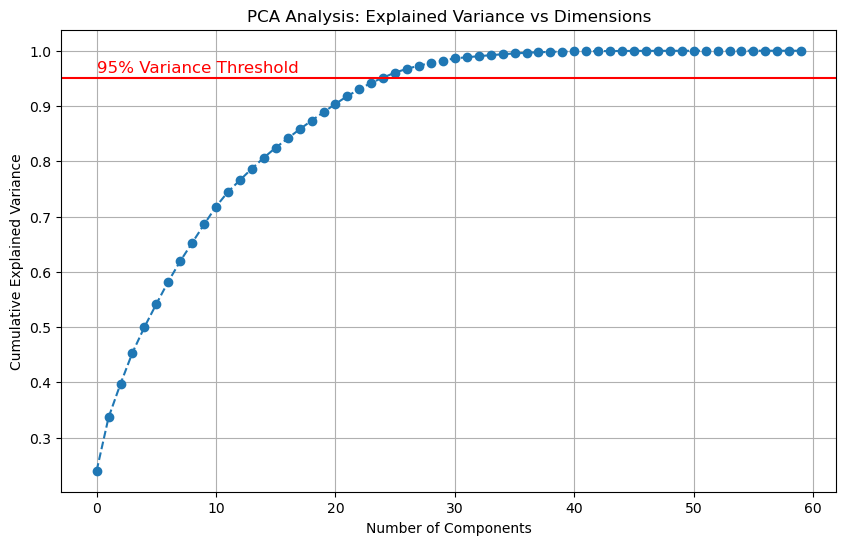

Number of components needed to explain 95% variance: 25
Original number of features: 60
Reduction ratio: 58.33% of features removed

--- Training Random Forest WITH PCA ---
PCA Random Forest trained in 145.31 seconds.
Accuracy with PCA: 0.9977


In [11]:
# --- 3. Dimension Reduction using PCA ---
from sklearn.decomposition import PCA
import numpy as np

# A. Analyze Variance Explained to choose n_components
# We need to scale data before PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Fit PCA without reducing dimension first to see the variance
pca = PCA()
pca.fit(X_train_scaled)

# Calculate cumulative variance
cumsum = np.cumsum(pca.explained_variance_ratio_)

# Plotting the variance
plt.figure(figsize=(10, 6))
plt.plot(cumsum, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Analysis: Explained Variance vs Dimensions')
plt.grid(True)
# Add a line for 95% variance threshold
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0, 0.96, '95% Variance Threshold', color = 'red', fontsize=12)
plt.show()

# Find exact number of components for 95% variance
n_components95 = np.argmax(cumsum >= 0.95) + 1
print(f"Number of components needed to explain 95% variance: {n_components95}")
print(f"Original number of features: {X_train.shape[1]}")
print(f"Reduction ratio: {100-(n_components95/X_train.shape[1]*100):.2f}% of features removed")

# B. Implement PCA in a new Pipeline
print("\n--- Training Random Forest WITH PCA ---")

pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n_components95)), # Keep 95% of information
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

start_time = time.time()
pca_pipeline.fit(X_train, y_train)
duration = time.time() - start_time

y_pred_pca = pca_pipeline.predict(X_test)
acc_pca = pca_pipeline.score(X_test, y_test)

print(f"PCA Random Forest trained in {duration:.2f} seconds.")
print(f"Accuracy with PCA: {acc_pca:.4f}")